In [12]:
# Fi = 411.38
# Ti = 2.43ms
# Record Length,Analog:1400000
# Sample Interval,CH:0.0000000020000
# Vertical Units, CH4:V,,,
# Vertical Scale, CH4:+1.000000E+00,,,
# Vertical Offset, CH4:+0.000000E+00,,,
# Horizontal Units,us,,,
# Horizontal Scale,200.0000000000,,,
# Model Number,SDS1104X-E,,,
# Serial Number,SDSMMEBX3R3314,,,
# Software Version,8.1.6.1.33,,,
# Source,CH4

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASE_CLK_FREQ = 300e6
BUFFER_SIZE = 4096
CE = 5

FS = 1/(((CE+1)/BASE_CLK_FREQ)*16)
fstep = FS / BUFFER_SIZE

data_out_df = pd.read_csv('/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/static_data/RAMP_buf4096_ce5_fs3.125M_hi2.0V_lo1.0V.csv')
input_df = pd.read_csv("/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/static_data/SDS00001.csv")

indices = np.linspace(0, len(input_df) - 1, 4096, dtype=int)

df_sampled = input_df.iloc[indices]
# data_out_df = (data_out_df["Value"] / 94.8) + 0.6


ramp_in = df_sampled["Volt"].to_list()
ramp_out = data_out_df["Value"].to_list()


# Convert input voltage to LSB (assuming 8-bit, so 256 levels)
vmin = min(ramp_in)
vmax = max(ramp_in)
ramp_in_lsb = [(v - vmin) / (vmax - vmin) * 255 for v in ramp_in]


In [13]:
ramp_in.sort()
ramp_out.sort()

ramp_in_lsb = [(v - vmin) / (vmax - vmin) * 255 for v in ramp_in]

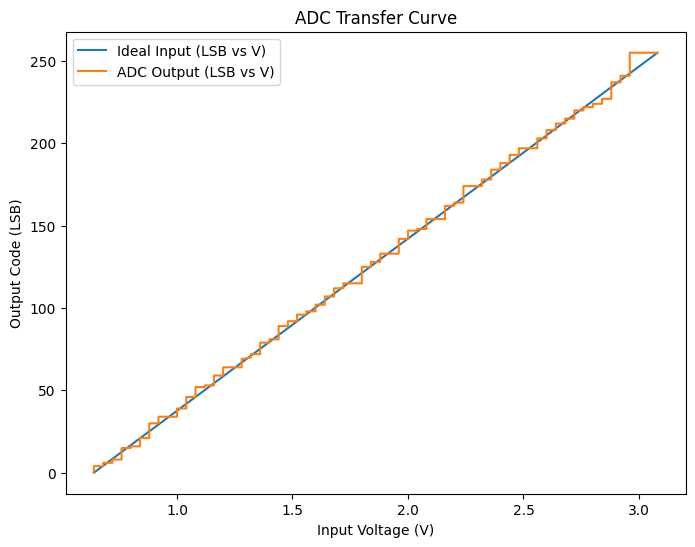

In [14]:

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(ramp_in, ramp_in_lsb, label='Ideal Input (LSB vs V)')
ax.plot(ramp_in, ramp_out,    label='ADC Output (LSB vs V)')

ax.set_xlabel('Input Voltage (V)')
ax.set_ylabel('Output Code (LSB)')
ax.set_title('ADC Transfer Curve')
ax.legend()
plt.show()


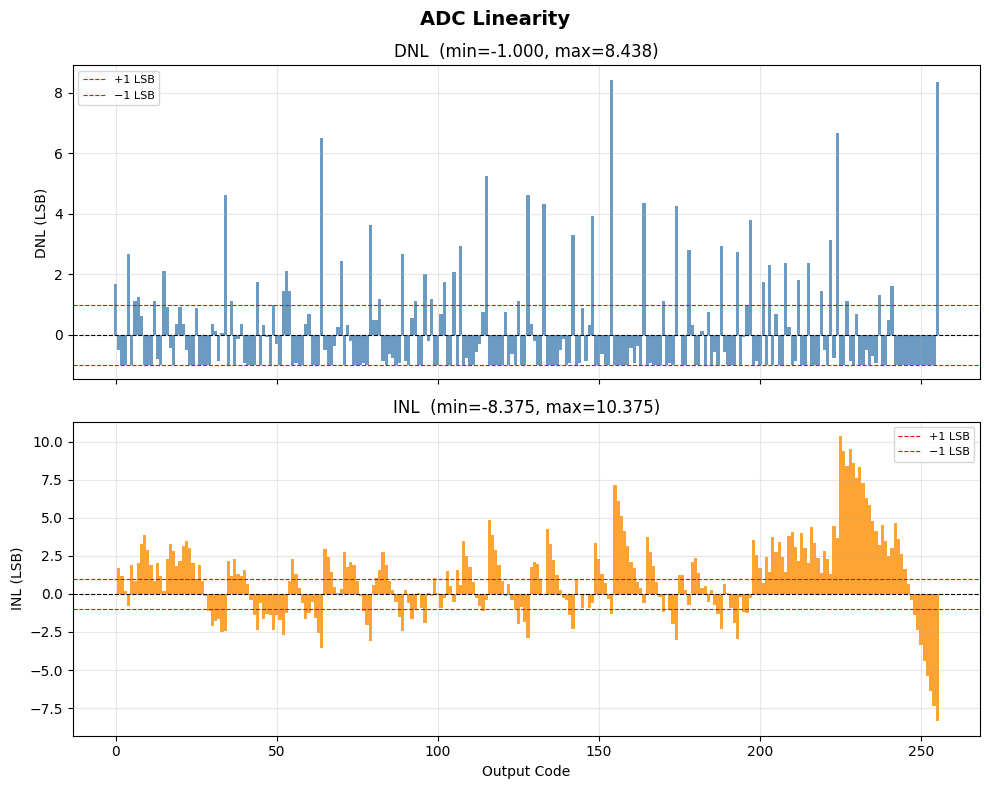

In [15]:
ramp_in.sort()
ramp_out.sort()
ramp_in_lsb = [(v - vmin) / (vmax - vmin) * 255 for v in ramp_in]

# --- Compute DNL and INL ---
ramp_out = np.array(ramp_out)
ramp_in_lsb = np.array(ramp_in_lsb)

# Find transition points for each code
num_codes = 256
code_bins = np.zeros(num_codes)
for code in range(num_codes):
    mask = ramp_out == code
    if mask.any():
        code_bins[code] = np.sum(mask)

ideal_bin_width = len(ramp_out) / num_codes

# DNL: deviation of each code width from ideal (in LSB)
dnl = (code_bins / ideal_bin_width) - 1.0

# INL: cumulative sum of DNL
inl = np.cumsum(dnl) - dnl  # endpoint convention

codes = np.arange(num_codes)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle('ADC Linearity', fontsize=14, fontweight='bold')

ax1.bar(codes, dnl, width=1.0, color='steelblue', alpha=0.8)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.axhline(1,  color='red', linewidth=0.8, linestyle='--', label='+1 LSB')
ax1.axhline(-1, color='red', linewidth=0.8, linestyle='--', label='−1 LSB')
ax1.set_ylabel('DNL (LSB)')
ax1.set_title(f'DNL  (min={dnl.min():.3f}, max={dnl.max():.3f})')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.bar(codes, inl, width=1.0, color='darkorange', alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.axhline(1,  color='red', linewidth=0.8, linestyle='--', label='+1 LSB')
ax2.axhline(-1, color='red', linewidth=0.8, linestyle='--', label='−1 LSB')
ax2.set_xlabel('Output Code')
ax2.set_ylabel('INL (LSB)')
ax2.set_title(f'INL  (min={inl.min():.3f}, max={inl.max():.3f})')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()